In [14]:
import numpy as np
import random
import torch
import torch.nn as nn
import torch.optim as optim
from collections import deque
import matplotlib.pyplot as plt
from copy import deepcopy


seed=115
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

# Implementation of DQN and Q-Leaning Algorithms for the Grid World Problem

### Grid World environment

In [15]:
class GridWorld:
    def __init__(self, size=7):
        self.size = size
        self.start = (0, 0)
        self.goal = (self.size-1, self.size-1)
        self.package = (2, 3)
        self.obstacles = [(1, 1), (2, 4), (3, 5), (4, 2), (5, 4)]
        
        self.max_energy = 100
        self.reset()
        
    def reset(self):
        self.agent_pos = self.start
        self.has_package = False
        self.energy = self.max_energy
        self.steps = 0
        self.collisions = 0
        self.done = False
        self.reward = 0
        self.package_pos = self.package
        return self._get_state()
    
    def _get_state(self):
      # state: [x_agent, y_agent, x_package, y_package, has_package]
        ax, ay = self.agent_pos
        px, py = self.package_pos
        if self.has_package:
            px, py = -1, -1  
        return np.array([ax / (self.size-1), ay / (self.size-1), 
                         px / (self.size-1), py / (self.size-1), 
                         float(self.has_package)], dtype=np.float32)
    
    def _is_valid(self, pos): # Is agent's position valid?
        x, y = pos
        if x < 0 or x >= self.size or y < 0 or y >= self.size:
            return False
        if pos in self.obstacles:
            return False
        return True
    
    def step(self, action): #  This function returns (next_state, reward, done, info)
        if self.done:
            return self._get_state(), 0, True, {}
        
        moves = [(-1, 0), (1, 0), (0, -1), (0, 1)]
        new_pos = (self.agent_pos[0] + moves[action][0], 
                   self.agent_pos[1] + moves[action][1])
        
        reward = 0
        info = {'collision': False, 'energy': self.energy}
        
        if not self._is_valid(new_pos):
            self.collisions += 1
            reward = -10
            info['collision'] = True
            # If the robot collides with an obstacle or wall, it will be penalized, but its position will not change.
        else:
            self.agent_pos = new_pos
            reward = -1  # Step penalty
        
        # Energy reduction
        self.energy -= 1
        self.steps += 1
        
        # Check package pickup
        if not self.has_package and self.agent_pos == self.package:
            self.has_package = True
            reward += 20  # Package pickup reward
            self.package_pos = (-1, -1)  # It means package is with the robot.
        
        # Checking the arrival at the target house
        if self.agent_pos == self.goal:
            if self.has_package:
                reward += 100  # Big reward for successful delivery
                self.done = True
                info['success'] = True
            else:
                reward -= 5   # Penalty for arriving without a package
                self.done = True
                info['success'] = False
        
        # Check energy depletion
        if self.energy <= 0:
            reward -= 20
            self.done = True
            info['success'] = False
        
        # If it gets long (more than 200 steps)
        if self.steps >= 200:
            self.done = True
            info['success'] = False
        
        self.reward = reward
        return self._get_state(), reward, self.done, info
    
    def render(self, path=None):
        grid = np.full((self.size, self.size), '.', dtype=str)
        for obs in self.obstacles:
            grid[obs] = 'X'
        grid[self.goal] = 'G'
        grid[self.package] = 'P'
        if path:
            for pos in path:
                if grid[pos] == '.':
                    grid[pos] = '*'
        grid[self.agent_pos] = 'A'
        print('\n'.join([' '.join(row) for row in grid]))
        print(f"Remained energy: {self.energy}, Steps: {self.steps}\n")

The GridWorld class creates a 7x7 grid. I defined fixed positions for the start point, the goal, the package, and obstacles. The robot always begins at the top-left corner (0,0), and goal is at the bottom-right corner(6,6).

In the _get_state method, state includes the robot's coordinates, the package's coordinates, and a flag showing whether the robot is carrying the package. I normalized all coordinates by dividing them by the grid size (values are between 0 and 1). If the robot has picked up the package, the package's position is set to -1 to show it is no longer on the grid.

The _is_valid method checks whether a given position is inside the grid and not blocked by an obstacle. When the robot moves, I calculate its new position. If the new position is outside the grid or an obstacle, the robot stays where it is and receives a penalty. If the move is valid, the robot moves to that new position. 

The step method handles one action at a time and returns the next state, the reward, whether the episode is over, and extra information. Each action costs one unit of energy and the robot gets -1 for each normal step to discourage longer paths. Colliding with an obstacle gives a -10 penalty. Picking up the package gives +20, and successfully delivering it to the goal gives +100. Running out of energy adds an extra -20 penalty. If it reaches the goal without the package, or if it runs out of energy, or if it takes more than 200 steps, the episode ends with failure.


The render method marks the robot as 'A', the goal as 'G', the package as 'P', obstacles as 'X', and empty cells as dots. it also marks the path with *.

### Implementing DQN Algorithm for Estimating Q-Values

In [16]:
class DQNNetwork(nn.Module):
    def __init__(self, state_dim=5, action_dim=4):
        super(DQNNetwork, self).__init__()
        self.fc1 = nn.Linear(state_dim, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, action_dim)
        self.relu = nn.ReLU()
        
    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        return self.fc3(x)


class ReplayBuffer:
    def __init__(self, capacity=10000):
        self.buffer = deque(maxlen=capacity)
    
    def push(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))
    
    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        states, actions, rewards, next_states, dones = zip(*batch)
        return (np.array(states), np.array(actions), np.array(rewards), 
                np.array(next_states), np.array(dones))
    
    def __len__(self):
        return len(self.buffer)


class DQNAgent:
    def __init__(self, state_dim=5, action_dim=4, lr=0.001, gamma=0.99,
                 epsilon_start=1.0, epsilon_end=0.01, epsilon_decay=0.995,
                 buffer_capacity=10000, batch_size=64, target_update=100):
        self.action_dim = action_dim
        self.gamma = gamma
        self.epsilon = epsilon_start
        self.epsilon_end = epsilon_end
        self.epsilon_decay = epsilon_decay
        self.batch_size = batch_size
        self.target_update = target_update
        self.update_counter = 0
        
        # Main and Target networks
        self.q_network = DQNNetwork(state_dim, action_dim)
        self.target_network = DQNNetwork(state_dim, action_dim)
        self.target_network.load_state_dict(self.q_network.state_dict())
        self.target_network.eval()
        

        self.optimizer = optim.Adam(self.q_network.parameters(), lr=lr)
        self.buffer = ReplayBuffer(buffer_capacity)
        
        self.losses = []
        
    def select_action(self, state, greedy=False):  # Choosing action with epsilon-greedy policy
        if greedy:
            with torch.no_grad():
                state_t = torch.FloatTensor(state).unsqueeze(0)
                q_values = self.q_network(state_t)
                return q_values.argmax().item()
        
        if random.random() < self.epsilon:
            return random.randint(0, self.action_dim - 1)
        else:
            with torch.no_grad():
                state_t = torch.FloatTensor(state).unsqueeze(0)
                q_values = self.q_network(state_t)
                return q_values.argmax().item()
    
    def update_epsilon(self):  # Epsilon Decay
        self.epsilon = max(self.epsilon_end, self.epsilon * self.epsilon_decay)
    
    def train_step(self):
        if len(self.buffer) < self.batch_size:
            return
        
        states, actions, rewards, next_states, dones = self.buffer.sample(self.batch_size)
        
        states = torch.FloatTensor(states)
        actions = torch.LongTensor(actions).unsqueeze(1)
        rewards = torch.FloatTensor(rewards).unsqueeze(1)
        next_states = torch.FloatTensor(next_states)
        dones = torch.FloatTensor(dones).unsqueeze(1)
        
        # Current Q-values
        current_q = self.q_network(states).gather(1, actions)
        
        with torch.no_grad():
            next_q = self.target_network(next_states).max(1, keepdim=True)[0]
            target_q = rewards + (1 - dones) * self.gamma * next_q   # Labels
        
        # Loss calculation and update
        loss = nn.MSELoss()(current_q, target_q)
        self.losses.append(loss.item())
        
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()
        
        # Update target network
        self.update_counter += 1
        if self.update_counter % self.target_update == 0:
            self.target_network.load_state_dict(self.q_network.state_dict())
    
    def save_model(self, path='best_dqn.pth'):
        torch.save(self.q_network.state_dict(), path)


The DQNNetwork class is a MLP that acts as an approximator for Q-values. It takes a 5-dimensional state vector as input (the robot's position, package position, and whether it has the package). The network has two hidden layers with 128 and 64 neurons and ReLU activation function. The output layer has 4 neurons (for each action (up, down, left, right)). The network learns to map each state to the expected future reward for each action.

The ReplayBuffer class stores the robot's experiences as tuples of (state, action, reward, next_state, done). It FIFO queue with a maximum size of 10,000 experiences. The push method adds new experiences to the buffer. The sample method randomly selects a batch of experiences, which breaks the correlation between consecutive samples.

The DQNAgent has two neural networks: the main network and a target network. The target network is a copy of the main network that gets updated periodically for example every 100 training steps. (This design prevents the learning from becoming unstable because the target values don't change too quickly.)

The select_action method balances exploration and exploitation using an epsilon-greedy policy. With probability epsilon, the agent takes a random action tand with probability 1-epsilon, it chooses the action with the highest Q-value according to its current network. The epsilon value starts at 1 to encourage exploration early in training, and gradually decays toward 0.01 to focus more on exploitation. The update_epsilon method handles this decay process. Also The select_action method has a greedy parameter. When greedy=True, the agent always picks the action with the highest Q-value and ignores exploration. This is used during test because we want to evaluate learned policy without random actions.

Labels(target Q-values) are calculated trough Bellman-equation:

target_Q_value = reward + γmax(Q(next_state, a'))

The reward comes from the environment after each action. The max Q-value for the next state comes from the target network.
The loss function is MSE function. It compares the current Q-value prediction against the calculated target.






### Tabular Q-learning

In [17]:
class TabularQLearning:
    def __init__(self, grid_size=7, action_dim=4, lr=0.1, gamma=0.99,
                 epsilon_start=1.0, epsilon_end=0.01, epsilon_decay=0.995):
        self.action_dim = action_dim
        self.lr = lr
        self.gamma = gamma
        self.epsilon = epsilon_start
        self.epsilon_end = epsilon_end
        self.epsilon_decay = epsilon_decay
        
        # Q table (state, action): (x, y, px, py, has_package, action) px , py are package's position
        self.Q = np.zeros((grid_size, grid_size, grid_size, grid_size, 2, action_dim))
        
    def _get_state_index(self, state): # Convert environment state to table index
        ax, ay, px, py, has_pkg = state
      
        if has_pkg == 1:
            px_idx, py_idx = 0, 0
        else:
            px_idx = int(px * (7-1))
            py_idx = int(py * (7-1))
        return (int(ax * (7-1)), int(ay * (7-1)), px_idx, py_idx, int(has_pkg))
    
    def select_action(self, state, greedy=False):
        if greedy:
            idx = self._get_state_index(state)
            return np.argmax(self.Q[idx])
        
        if random.random() < self.epsilon:
            return random.randint(0, self.action_dim - 1)
        else:
            idx = self._get_state_index(state)
            return np.argmax(self.Q[idx])
    
    def update_epsilon(self):
        self.epsilon = max(self.epsilon_end, self.epsilon * self.epsilon_decay)
    
    def update(self, state, action, reward, next_state, done):
        idx = self._get_state_index(state)
        next_idx = self._get_state_index(next_state)
        
        best_next = np.max(self.Q[next_idx])
        target = reward + (1 - done) * self.gamma * best_next
        self.Q[idx][action] += self.lr * (target - self.Q[idx][action])


Tabular Q-Learning stores the Q-value for every state-action pair in a table. It works when the state space is small enough to store all combinations.

The Q-table is a 6-dimensional numpy array. First two dimensions are robot's position. 
Third and fourth dimensions are package position but when the robot has the package, these are set to 0.
Fifth dimension shows if the robot has the package. Sixth dimension is the 4 possible actions (up, down, left, right)

The select_action method works similarly to the DQN version. When greedy=True, it always picks the action with the highest Q-value from the Q-table. When greedy=False, it uses epsilon-greedy approach. Sometimes it picks a random action, otherwise it picks the best action(exploitation).

The update rule used in the update method is based on the Bellman equation. The term (1 - done) ensures that when the episode ends, we don't include future rewards because there is no next state.


In [18]:
def run_episode(env, agent, train=True, agent_type='dqn'): # Run an episode
    state = env.reset()
    done = False
    total_reward = 0
    steps = 0
    collisions = 0
    
    while not done:
        # Choosing action
        if agent_type == 'dqn':
            action = agent.select_action(state, greedy=not train)
        elif agent_type == 'q':
            action = agent.select_action(state, greedy=not train)
        else:  # random agent
            action = random.randint(0, 3)
        
      # Step execution
        next_state, reward, done, info = env.step(action)
        
      
        if agent_type == 'dqn' and train:
            agent.buffer.push(state, action, reward, next_state, done)
            agent.train_step()
        elif agent_type == 'q' and train:
            agent.update(state, action, reward, next_state, done)
        
        total_reward += reward
        steps += 1
        if info.get('collision', False):
            collisions += 1
        state = next_state
    
    return total_reward, steps, collisions, env.energy, info.get('success', False)

def train_agent(env, agent, agent_type='dqn', episodes=300, eval_interval=10):
    rewards_history = []
    success_history = []
    length_history = []
    collision_history = []
    energy_history = []
    best_reward = -float('inf')
    
    for ep in range(1, episodes + 1):
        total_reward, steps, collisions, energy, success = run_episode(
            env, agent, train=True, agent_type=agent_type
        )
        
        if agent_type == 'dqn' or agent_type == 'q':
            agent.update_epsilon()
        

        rewards_history.append(total_reward)
        success_history.append(1 if success else 0)
        length_history.append(steps)
        collision_history.append(collisions)
        energy_history.append(energy)
        
        # Periodic evaluation
        if ep % eval_interval == 0:
            avg_reward = np.mean(rewards_history[-eval_interval:])
            avg_success = np.mean(success_history[-eval_interval:])
            print(f"Episode {ep}: Average reward={avg_reward:.2f}, Success rate={avg_success:.2f}, "
                  f"Energy={np.mean(energy_history[-eval_interval:]):.1f}, Epsilon={agent.epsilon:.3f}")
            
            # Save the best model (for DQN)
            if agent_type == 'dqn' and avg_reward > best_reward:
                best_reward = avg_reward
                agent.save_model('best_dqn.pth')
    
    return rewards_history, success_history, length_history, collision_history, energy_history

def evaluate_agent(env, agent, agent_type='dqn', num_episodes=100):  # Final evaluation of the agent (without exploration)
    rewards = []
    successes = []
    lengths = []
    collisions = []
    energies = []
    
    for _ in range(num_episodes):
        total_reward, steps, coll, energy, success = run_episode(
            env, agent, train=False, agent_type=agent_type
        )
        rewards.append(total_reward)
        successes.append(1 if success else 0)
        lengths.append(steps)
        collisions.append(coll)
        energies.append(energy)
    
    return {
        'mean_reward': np.mean(rewards),
        'success_rate': np.mean(successes),
        'mean_length': np.mean(lengths),
        'mean_collisions': np.mean(collisions),
        'mean_energy': np.mean(energies),
    }



DQN Agent Training...
Episode 10: Average reward=-344.70, Success rate=0.00, Energy=0.0, Epsilon=0.951
Episode 20: Average reward=-325.10, Success rate=0.10, Energy=2.2, Epsilon=0.905
Episode 30: Average reward=-321.80, Success rate=0.00, Energy=0.0, Epsilon=0.860
Episode 40: Average reward=-296.30, Success rate=0.00, Energy=0.0, Epsilon=0.818
Episode 50: Average reward=-293.90, Success rate=0.00, Energy=0.0, Epsilon=0.778
Episode 60: Average reward=-307.40, Success rate=0.00, Energy=0.0, Epsilon=0.740
Episode 70: Average reward=-238.40, Success rate=0.20, Energy=0.9, Epsilon=0.704
Episode 80: Average reward=-209.40, Success rate=0.30, Energy=10.2, Epsilon=0.670
Episode 90: Average reward=-122.00, Success rate=0.70, Energy=26.7, Epsilon=0.637
Episode 100: Average reward=-119.00, Success rate=0.70, Energy=40.1, Epsilon=0.606
Episode 110: Average reward=-0.80, Success rate=1.00, Energy=59.3, Epsilon=0.576
Episode 120: Average reward=-25.40, Success rate=1.00, Energy=52.7, Epsilon=0.548


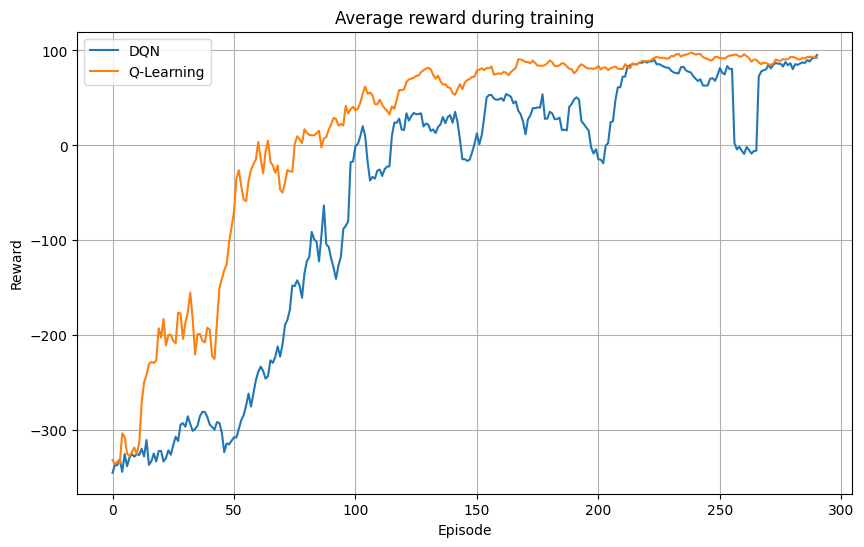

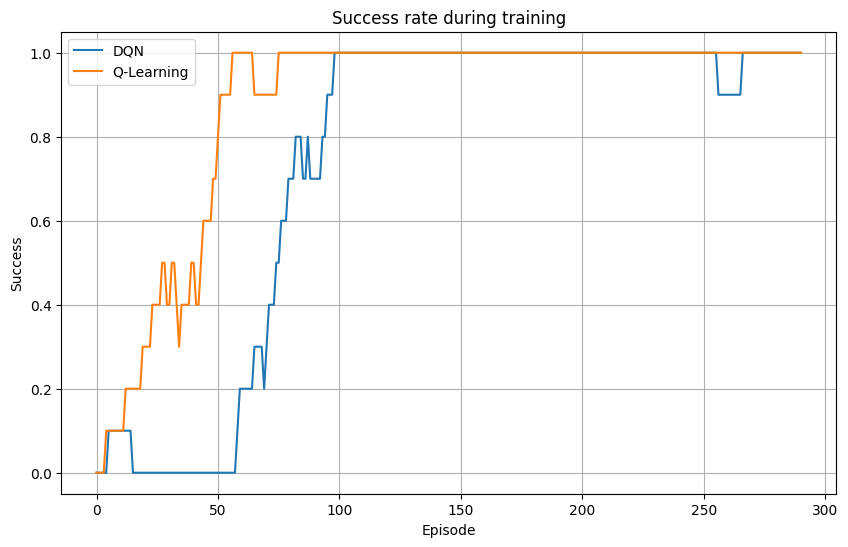

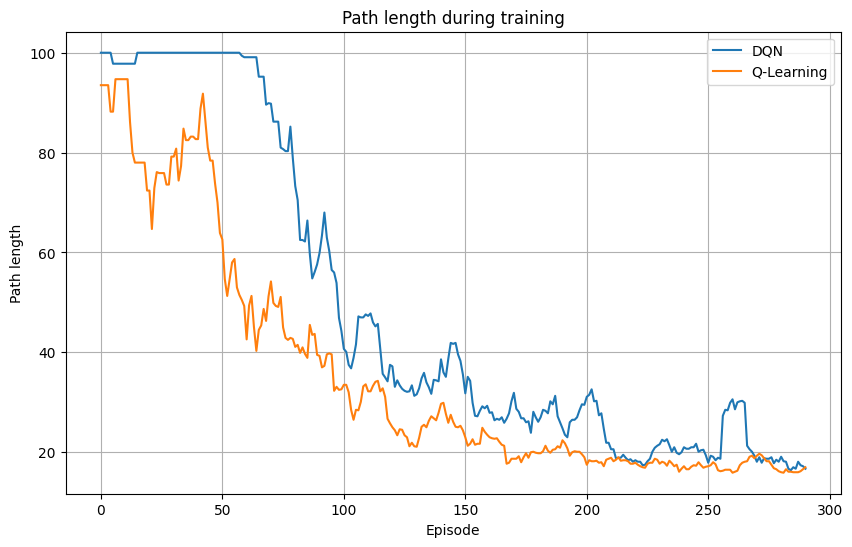

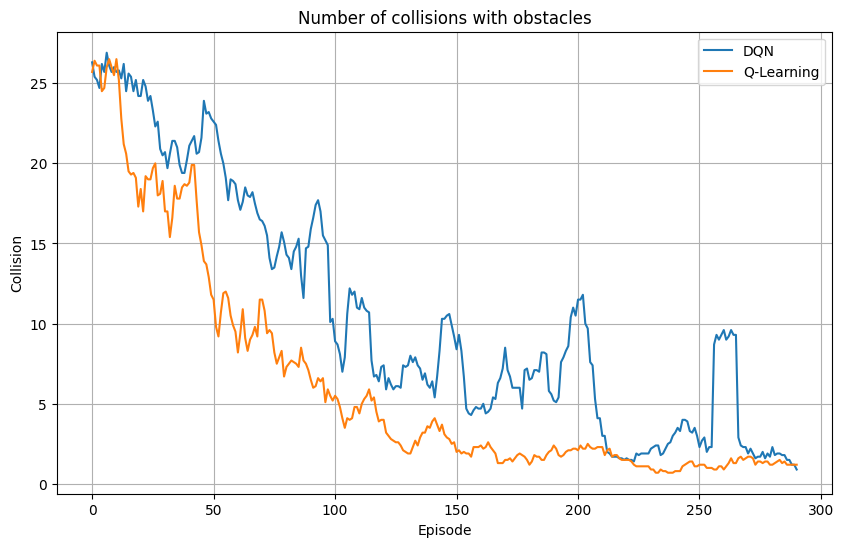

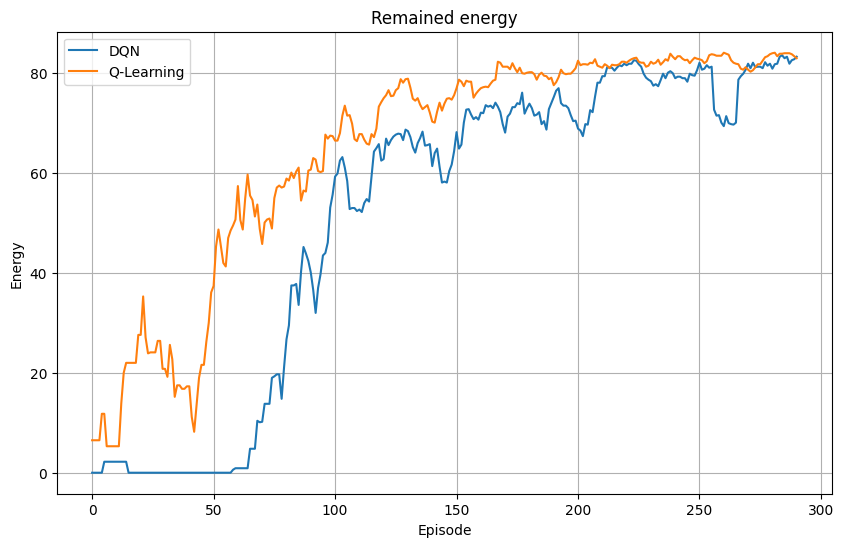


Final DQN Agent Path:
* . . . . . .
* X . . . . .
* * * P X . .
. . . * . X .
. . X * . . .
. . . * X . .
. . . * * * A
Remained energy: 88, Steps: 12


Final Q-learning Agent Path:
* * * . . . .
. X * * . . .
. . . P X . .
. . . * . X .
. . X * * * *
. . . . X . *
. . . . . . A
Remained energy: 88, Steps: 12



In [19]:
def plot_results(data_dict, title, ylabel):
    plt.figure(figsize=(10, 6))
    for label, values in data_dict.items():
   # Moving average with window size of 10
        smoothed = np.convolve(values, np.ones(10)/10, mode='valid')
        plt.plot(smoothed, label=label)
    plt.xlabel('Episode')
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()


env = GridWorld(size=7)


print("\nDQN Agent Training...")
dqn_agent = DQNAgent(state_dim=5, action_dim=4)
dqn_rewards, dqn_success, dqn_length, dqn_collision, dqn_energy = train_agent(
    env, dqn_agent, agent_type='dqn', episodes=300
)


print("\nQ-learning Agent Training...")
q_agent = TabularQLearning(grid_size=7, action_dim=4)
q_rewards, q_success, q_length, q_collision, q_energy = train_agent(
    env, q_agent, agent_type='q', episodes=300
)


print("\nRandom Agent...")
random_results = []
for _ in range(100):
    state = env.reset()
    done = False
    total_r, steps, coll, energy, success = 0, 0, 0, env.energy, False
    while not done:
        action = random.randint(0, 3)
        _, reward, done, info = env.step(action)
        total_r += reward
        steps += 1
        if info.get('collision', False):
            coll += 1
        energy = env.energy
    random_results.append({'reward': total_r, 'success': success, 'length': steps, 
                          'collisions': coll, 'energy': energy})

random_stats = {
    'mean_reward': np.mean([r['reward'] for r in random_results]),
    'success_rate': np.mean([r['success'] for r in random_results]),
    'mean_length': np.mean([r['length'] for r in random_results]),
    'mean_collisions': np.mean([r['collisions'] for r in random_results]),
    'mean_energy': np.mean([r['energy'] for r in random_results]),
}


print("\nFinal evaluation for 100 episodes...")
dqn_eval = evaluate_agent(env, dqn_agent, 'dqn')
q_eval = evaluate_agent(env, q_agent, 'q')

print("DQN:", dqn_eval)
print("Q-Learning:", q_eval)
print("Random:", random_stats)


plot_results({'DQN': dqn_rewards, 'Q-Learning': q_rewards}, 
             'Average reward during training', 'Reward')


plot_results({'DQN': dqn_success, 'Q-Learning': q_success}, 
             'Success rate during training', 'Success')


plot_results({'DQN': dqn_length, 'Q-Learning': q_length}, 
             'Path length during training', 'Path length')


plot_results({'DQN': dqn_collision, 'Q-Learning': q_collision}, 
             'Number of collisions with obstacles', 'Collision')


plot_results({'DQN': dqn_energy, 'Q-Learning': q_energy}, 
             'Remained energy', 'Energy')


print("\nFinal DQN Agent Path:")
# Loading the best model
best_dqn = DQNAgent(state_dim=5, action_dim=4)
best_dqn.q_network.load_state_dict(torch.load('best_dqn.pth'))

state = env.reset()
done = False
path = [env.agent_pos]
while not done:
    action = best_dqn.select_action(state, greedy=True)
    next_state, _, done, _ = env.step(action)
    path.append(env.agent_pos)
    state = next_state
env.render(path)


print("\nFinal Q-learning Agent Path:")
state = env.reset()
done = False
path = [env.agent_pos]
while not done:
    action = q_agent.select_action(state, greedy=True)
    next_state, _, done, _ = env.step(action)
    path.append(env.agent_pos)
    state = next_state
env.render(path)

### Analysis:
During the early episodes, the agents performed poorly with negative rewards and a very low success rate. The low remaining energy indicates that the robot was running out of energy before completing the task. The high epsilon value means the agents were mostly taking random actions, which explains their poor performance.

In the middle episodes, we can see improvement. The average reward increased substantially, and the success rate reached a high level. The remaining energy also improved, indicating that the robot was learning to complete the task more efficiently and finding the correct path.

By the final episodes, agents achieved a perfect success rate. The rewards became positive, and the remaining energy stabilized at a good level. The models converged well, though there was some fluctuation in performance between episodes especially in DQN agent.


Looking at all five graphs, we can see Q-Learning converges faster than DQN and DQN Shows more fluctuation (higher variance), noise and instability throughout training because DQN uses a neural network to approximate Q-values which are not perfect approximators, especially with limited training data. The network constantly adjusts its weights, and sometimes these adjustments move in the wrong direction, causing temporary performance drops. Q-Learning uses an exact Q-table, so there's no approximation error. In addition DQN samples random mini-batches from the replay buffer. The composition of these batches varies each time, which can lead to different gradient updates and cause fluctuations in performance. Sometimes the agent gets good batches that reinforce good behavior, and sometimes it gets bad ones that temporarily confuse it. Also DQN uses a separate target network that updates periodically. When the target network updates, the target values change suddenly, which can cause a temporary dip in performance until the main network adapts. This creates the sawtooth pattern often seen in DQN learning curves.





In [ ]:
import pygame
import sys
import os
import csv
from datetime import datetime

pygame.init()

class PygameRenderer:
  
    def __init__(self, env, cell_size=80, delay=200):
        self.env = env
        self.cell_size = cell_size
        self.delay = delay
        self.width = env.size * cell_size
        self.height = env.size * cell_size
        self.screen = pygame.display.set_mode((self.width, self.height))
        pygame.display.set_caption("Grid World")
        

        self.COLORS = {
            'background': (255, 255, 255),   
            'grid': (200, 200, 200),       
            'agent': (0, 150, 255),        
            'agent_has_package': (0, 255, 150), 
            'package': (255, 200, 0),       
            'goal': (0, 255, 0),            
            'obstacle': (255, 50, 50),       
            'path': (100, 200, 255, 128),  
            'success': (0, 255, 0, 150),    
            'fail': (255, 0, 0, 150),      
            'text': (0, 0, 0),              
        }
        
        self.clock = pygame.time.Clock()
        self.path = []
        
    def draw_grid(self):
        for i in range(self.env.size + 1):
            pygame.draw.line(self.screen, self.COLORS['grid'], 
                           (i * self.cell_size, 0), 
                           (i * self.cell_size, self.height))
            pygame.draw.line(self.screen, self.COLORS['grid'], 
                           (0, i * self.cell_size), 
                           (self.width, i * self.cell_size))
    
    def draw_cell(self, pos, color, alpha=255):
        x, y = pos
        rect = pygame.Rect(x * self.cell_size, y * self.cell_size, 
                          self.cell_size, self.cell_size)
        if alpha < 255:
            s = pygame.Surface((self.cell_size, self.cell_size), pygame.SRCALPHA)
            s.fill((*color, alpha))
            self.screen.blit(s, rect)
        else:
            pygame.draw.rect(self.screen, color, rect)
    
    def draw_obstacles(self):
        for obs in self.env.obstacles:
            self.draw_cell(obs, self.COLORS['obstacle'])
            x, y = obs
            center_x = x * self.cell_size + self.cell_size // 2
            center_y = y * self.cell_size + self.cell_size // 2
            offset = self.cell_size // 3
            pygame.draw.line(self.screen, (200, 0, 0), 
                           (center_x - offset, center_y - offset),
                           (center_x + offset, center_y + offset), 3)
            pygame.draw.line(self.screen, (200, 0, 0),
                           (center_x + offset, center_y - offset),
                           (center_x - offset, center_y + offset), 3)
    
    def draw_goal(self):
        self.draw_cell(self.env.goal, self.COLORS['goal'])
        font = pygame.font.Font(None, 36)
        text = font.render('G', True, (0, 100, 0))
        x, y = self.env.goal
        self.screen.blit(text, (x * self.cell_size + self.cell_size//3, 
                               y * self.cell_size + self.cell_size//4))
    
    def draw_package(self):
        if not self.env.has_package:
            self.draw_cell(self.env.package, self.COLORS['package'])
            font = pygame.font.Font(None, 36)
            text = font.render('P', True, (150, 100, 0))
            x, y = self.env.package
            self.screen.blit(text, (x * self.cell_size + self.cell_size//3, 
                                   y * self.cell_size + self.cell_size//4))
    
    def draw_agent(self):
        color = self.COLORS['agent_has_package'] if self.env.has_package else self.COLORS['agent']
        x, y = self.env.agent_pos
        center_x = x * self.cell_size + self.cell_size // 2
        center_y = y * self.cell_size + self.cell_size // 2
        radius = self.cell_size // 3
        pygame.draw.circle(self.screen, color, (center_x, center_y), radius)
        pygame.draw.circle(self.screen, (0, 0, 0), 
                          (center_x - radius//3, center_y - radius//3), 4)
        pygame.draw.circle(self.screen, (0, 0, 0),
                          (center_x + radius//3, center_y - radius//3), 4)
        if self.env.has_package:
            pygame.draw.circle(self.screen, self.COLORS['package'],
                             (center_x, center_y + radius//2), 6)
    
    def draw_path(self):
        for i, pos in enumerate(self.path):
            alpha = int(80 + 80 * (i / max(1, len(self.path))))
            self.draw_cell(pos, self.COLORS['path'][:3], alpha=min(alpha, 180))
    
    def draw_status(self):
        font = pygame.font.Font(None, 24)
        status_text = f"Energy: {self.env.energy}  Steps: {self.env.steps}  "
        status_text += f"Package: {'Yes' if self.env.has_package else 'No'}  "
        status_text += f"Episode: {'Success' if self.env.done and self.env.reward > 0 else 'Running'}"
        
        text_surface = font.render(status_text, True, self.COLORS['text'])
        text_rect = text_surface.get_rect()
        text_rect.topleft = (10, self.height - 30)
        pygame.draw.rect(self.screen, (255, 255, 255, 200), 
                        (text_rect.x - 5, text_rect.y - 5, 
                         text_rect.width + 10, text_rect.height + 10))
        self.screen.blit(text_surface, text_rect)
    
    def render_episode(self, agent, agent_type='dqn', greedy=True):
        state = self.env.reset()
        self.path = [self.env.agent_pos]
        done = False
        success = False
        
        while not done:
            for event in pygame.event.get():
                if event.type == pygame.QUIT:
                    pygame.quit()
                    sys.exit()
                if event.type == pygame.KEYDOWN:
                    if event.key == pygame.K_SPACE:
                        self.wait_for_continue()
                    if event.key == pygame.K_ESCAPE: 
                        pygame.quit()
                        sys.exit()
            
            if agent_type == 'dqn':
                action = agent.select_action(state, greedy=greedy)
            elif agent_type == 'q':
                action = agent.select_action(state, greedy=greedy)
            else:  
                action = random.randint(0, 3)
            
            next_state, reward, done, info = self.env.step(action)
            

            if not done:
                self.path.append(self.env.agent_pos)
            

            self.screen.fill(self.COLORS['background'])
            self.draw_grid()
            self.draw_path()
            self.draw_obstacles()
            self.draw_goal()
            self.draw_package()
            self.draw_agent()
            self.draw_status()
            

            if done:
                success = info.get('success', False)
                self.show_episode_end(success)
            
            pygame.display.flip()
            self.clock.tick(60)  
            pygame.time.wait(self.delay)  
            
            state = next_state
        
        return success
    
    def wait_for_continue(self):
        paused = True
        while paused:
            for event in pygame.event.get():
                if event.type == pygame.QUIT:
                    pygame.quit()
                    sys.exit()
                if event.type == pygame.KEYDOWN:
                    if event.key == pygame.K_SPACE:
                        paused = False
                    if event.key == pygame.K_ESCAPE:
                        pygame.quit()
                        sys.exit()
    
    def show_episode_end(self, success):
        font = pygame.font.Font(None, 72)
        if success:
            text = font.render('SUCCESS!', True, (0, 200, 0))
            for _ in range(10):
                self.screen.fill(self.COLORS['background'])
                self.draw_grid()
                self.draw_path()
                self.draw_obstacles()
                self.draw_goal()
                self.draw_package()
                self.draw_agent()
                text_surface = font.render('SUCCESS!', True, (0, 200, 0))
                self.screen.blit(text_surface, (self.width//2 - 100, self.height//2 - 50))
                pygame.display.flip()
                pygame.time.wait(100)
        else:
            text = font.render('FAILED!', True, (200, 0, 0))
            self.screen.blit(text, (self.width//2 - 100, self.height//2 - 50))
            pygame.display.flip()
            pygame.time.wait(1000)



def save_results_to_csv(results, filename=None):
    if filename is None:
        timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
        filename = f"results_{timestamp}.csv"
    
    with open(filename, 'w', newline='', encoding='utf-8') as csvfile:
        fieldnames = ['Algorithm', 'Mean_Reward', 'Success_Rate', 'Mean_Length', 
                     'Mean_Collisions', 'Mean_Energy', 'Std_Reward']
        writer = csv.DictWriter(csvfile, fieldnames=fieldnames)
        writer.writeheader()
        
        for algo, data in results.items():
            writer.writerow({
                'Algorithm': algo,
                'Mean_Reward': data['mean_reward'],
                'Success_Rate': data['success_rate'],
                'Mean_Length': data['mean_length'],
                'Mean_Collisions': data['mean_collisions'],
                'Mean_Energy': data['mean_energy'],
            })
    
    print(f"Results saved to file {filename}.")
    return filename



def train_agent(env, agent, agent_type='dqn', episodes=300, eval_interval=10):
    rewards_history = []
    success_history = []
    length_history = []
    collision_history = []
    energy_history = []
    best_reward = -float('inf')
    
    for ep in range(1, episodes + 1):
        total_reward, steps, collisions, energy, success = run_episode(
            env, agent, train=True, agent_type=agent_type
        )
        
        if agent_type == 'dqn' or agent_type == 'q':
            agent.update_epsilon()
        
        rewards_history.append(total_reward)
        success_history.append(1 if success else 0)
        length_history.append(steps)
        collision_history.append(collisions)
        energy_history.append(energy)
        
        if ep % eval_interval == 0:
            avg_reward = np.mean(rewards_history[-eval_interval:])
            avg_success = np.mean(success_history[-eval_interval:])
            print(f"Episode {ep}: Avg Reward={avg_reward:.2f}, Success Rate={avg_success:.2f}, Epsilon={agent.epsilon:.3f}")
            
            if agent_type == 'dqn' and avg_reward > best_reward:
                best_reward = avg_reward
                agent.save_model('best_dqn.pth')
    
    return rewards_history, success_history, length_history, collision_history, energy_history


def run_episode(env, agent, train=True, agent_type='dqn'):
    state = env.reset()
    done = False
    total_reward = 0
    steps = 0
    collisions = 0
    
    while not done:
        if agent_type == 'dqn':
            action = agent.select_action(state, greedy=not train)
        elif agent_type == 'q':
            action = agent.select_action(state, greedy=not train)
        else:
            action = random.randint(0, 3)
        
        next_state, reward, done, info = env.step(action)
        
        if agent_type == 'dqn' and train:
            agent.buffer.push(state, action, reward, next_state, done)
            agent.train_step()
        elif agent_type == 'q' and train:
            agent.update(state, action, reward, next_state, done)
        
        total_reward += reward
        steps += 1
        if info.get('collision', False):
            collisions += 1
        state = next_state
    
    return total_reward, steps, collisions, env.energy, info.get('success', False)


def evaluate_agent(env, agent, agent_type='dqn', num_episodes=100):
    rewards = []
    successes = []
    lengths = []
    collisions = []
    energies = []
    
    for _ in range(num_episodes):
        total_reward, steps, coll, energy, success = run_episode(
            env, agent, train=False, agent_type=agent_type
        )
        rewards.append(total_reward)
        successes.append(1 if success else 0)
        lengths.append(steps)
        collisions.append(coll)
        energies.append(energy)
    
    return {
        'mean_reward': np.mean(rewards),
        'success_rate': np.mean(successes),
        'mean_length': np.mean(lengths),
        'mean_collisions': np.mean(collisions),
        'mean_energy': np.mean(energies),
    }


env = GridWorld(size=7)
    
dqn_agent = DQNAgent(state_dim=5, action_dim=4)
try:
    dqn_agent.q_network.load_state_dict(torch.load('best_dqn.pth'))
    print("DQN model loaded.")
except:
    print("DQN model not found, training new model.")
    train_agent(env, dqn_agent, agent_type='dqn', episodes=300)
    
q_agent = TabularQLearning(grid_size=7, action_dim=4)
print("Training Q-Learning...")
q_rewards, q_success, q_length, q_collision, q_energy = train_agent(
    env, q_agent, agent_type='q', episodes=300
)

random_results = []
for _ in range(100):
    state = env.reset()
    done = False
    total_r, steps, coll, energy, success = 0, 0, 0, env.energy, False
    while not done:
        action = random.randint(0, 3)
        _, reward, done, info = env.step(action)
        total_r += reward
        steps += 1
        if info.get('collision', False):
            coll += 1
        energy = env.energy
    random_results.append({'reward': total_r, 'success': success, 'length': steps, 
                          'collisions': coll, 'energy': energy})

random_stats = {
    'mean_reward': np.mean([r['reward'] for r in random_results]),
    'success_rate': np.mean([r['success'] for r in random_results]),
    'mean_length': np.mean([r['length'] for r in random_results]),
    'mean_collisions': np.mean([r['collisions'] for r in random_results]),
    'mean_energy': np.mean([r['energy'] for r in random_results]),
}

dqn_eval = evaluate_agent(env, dqn_agent, 'dqn')
q_eval = evaluate_agent(env, q_agent, 'q')
    
results = {
    'DQN': dqn_eval,
    'Q-Learning': q_eval,
    'Random': random_stats
}
    
csv_file = save_results_to_csv(results)
    
renderer = PygameRenderer(env, cell_size=80, delay=300)

success = renderer.render_episode(dqn_agent, agent_type='dqn', greedy=True)
print(f"DQN episode result: {'successful' if success else 'failed'}")
    
pygame.time.wait(1000)
    
success = renderer.render_episode(q_agent, agent_type='q', greedy=True)
print(f"Q-learning episode result: {'successful' if success else 'failed'}")

success = renderer.render_episode(None, agent_type='random', greedy=False)
print(f"Random episode result: {'successful' if success else 'failed'}")
    
pygame.quit()

DQN model loaded.
Training Q-Learning...
Episode 10: Avg Reward=-265.60, Success Rate=0.00, Epsilon=0.951
Episode 20: Avg Reward=-308.50, Success Rate=0.10, Epsilon=0.905
Episode 30: Avg Reward=-281.50, Success Rate=0.20, Epsilon=0.860
Episode 40: Avg Reward=-173.70, Success Rate=0.60, Epsilon=0.818
Episode 50: Avg Reward=-187.70, Success Rate=0.40, Epsilon=0.778
Episode 60: Avg Reward=-111.20, Success Rate=0.70, Epsilon=0.740
Episode 70: Avg Reward=-6.00, Success Rate=1.00, Epsilon=0.704
Episode 80: Avg Reward=-20.60, Success Rate=0.90, Epsilon=0.670
Episode 90: Avg Reward=19.00, Success Rate=1.00, Epsilon=0.637
Episode 100: Avg Reward=34.60, Success Rate=1.00, Epsilon=0.606
Episode 110: Avg Reward=46.00, Success Rate=1.00, Epsilon=0.576
Episode 120: Avg Reward=39.80, Success Rate=1.00, Epsilon=0.548
Episode 130: Avg Reward=54.60, Success Rate=1.00, Epsilon=0.521
Episode 140: Avg Reward=55.60, Success Rate=1.00, Epsilon=0.496
Episode 150: Avg Reward=69.40, Success Rate=1.00, Epsilon=0